# 2주차 실습 — Fingerprint를 바꾸면 유사물질도 바뀐다

## 0. 준비

VS Code에서 `Python (med-exp)` kernel을 선택합니다.

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw

mol = Chem.MolFromSmiles("CCC1c(CO)ccc1C(=O)CO")
image = Draw.MolToImage(mol)

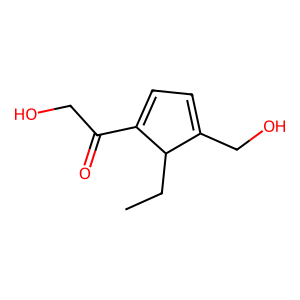

In [2]:
image

In [3]:
from pathlib import Path
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw, MACCSkeys, rdFingerprintGenerator, rdFMCS, rdMolDescriptors

## 1. Query와 Ref_list 불러오기

In [4]:
DATA_DIR = Path("data")
Query = pd.read_csv(DATA_DIR / "query.csv")
Ref_list = pd.read_csv(DATA_DIR / "Ref_list.csv")

In [5]:
Query

,query_id,SMILES
0,Q-01,CCCOC(=O)c1ccc(O)cc1


In [6]:
Ref_list.head(5)

,reference_id,SMILES,skin_reaction
0,AUG-0001,CCCCCCCCCCCCCBr,1
1,AUG-0002,CN(C)CCCN,1
2,AUG-0003,O=C1C=CC(=O)O1,1
3,AUG-0004,NCCNCCO,1
4,AUG-0005,Oc1c(Cl)c(Cl)c(Cl)c(Cl)c1Cl,1


## 2. SMILES를 Mol object로 바꾸기

In [7]:
# SMILES 열에 있는 첫번째 문자열이 query_smiles에 저장 (아직은 문자열 상태)
query_smiles = Query.loc[0, "SMILES"]
# SMILES 문자열을 Mol object로 변환
query_mol = Chem.MolFromSmiles(query_smiles)

In [8]:
print(query_smiles, "&", type(query_smiles))

CCCOC(=O)c1ccc(O)cc1 & <class 'str'>


In [9]:
print(query_mol, "&", type(query_mol))

<rdkit.Chem.rdchem.Mol object at 0x00000266D3503AE0> & <class 'rdkit.Chem.rdchem.Mol'>


In [10]:
Ref_list.head()

,reference_id,SMILES,skin_reaction
0,AUG-0001,CCCCCCCCCCCCCBr,1
1,AUG-0002,CN(C)CCCN,1
2,AUG-0003,O=C1C=CC(=O)O1,1
3,AUG-0004,NCCNCCO,1
4,AUG-0005,Oc1c(Cl)c(Cl)c(Cl)c(Cl)c1Cl,1


In [11]:
Ref_smiles_list = Ref_list["SMILES"].tolist()

for i, ref_smiles in enumerate(Ref_smiles_list):
    ref_mol = Chem.MolFromSmiles(ref_smiles)
    Ref_list.at[i, "mol"] = ref_mol

# or 더 쉬운 방법을 써도 된다. 아래는 AI가 주로 사용하는 한 줄짜리 방법.
# Ref_list["mol"] = Ref_list["SMILES"].apply(Chem.MolFromSmiles)

In [12]:
Ref_list.head()

,reference_id,SMILES,skin_reaction,mol
0,AUG-0001,CCCCCCCCCCCCCBr,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...
1,AUG-0002,CN(C)CCCN,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...
2,AUG-0003,O=C1C=CC(=O)O1,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...
3,AUG-0004,NCCNCCO,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...
4,AUG-0005,Oc1c(Cl)c(Cl)c(Cl)c(Cl)c1Cl,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...


## 3. Query + Top 5를 그리는 함수 (def는 선언만 한다.)

In [13]:
def candidate_colors(query, candidate):
    result = rdFMCS.FindMCS([query, candidate], atomCompare=rdFMCS.AtomCompare.CompareElements, bondCompare=rdFMCS.BondCompare.CompareOrder, ringMatchesRingOnly=True, completeRingsOnly=True, timeout=5)
    pattern = Chem.MolFromSmarts(result.smartsString)
    common = set(candidate.GetSubstructMatch(pattern))
    atoms = list(range(candidate.GetNumAtoms()))
    colors = {i: ((0.60, 0.90, 0.64) if i in common else (1.00, 0.65, 0.32)) for i in atoms}
    return atoms, colors

def draw_top5(top5, score_col, title):
    mols = [query_mol] + top5["mol"].tolist()
    legends = [f"QUERY | propyl paraben\n{query_smiles}"]
    atom_lists = [list(range(query_mol.GetNumAtoms()))]
    color_lists = [{i: (0.65, 0.78, 1.00) for i in range(query_mol.GetNumAtoms())}]
    for rank, (_, row) in enumerate(top5.iterrows(), 1):
        atoms, colors = candidate_colors(query_mol, row["mol"])
        legends.append(f"#{rank} {row['reference_id']} | Tanimoto {row[score_col]:.3f}\nskin_reaction={int(row['skin_reaction'])}")
        atom_lists.append(atoms); color_lists.append(colors)
    print(title)
    return Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(360,270), legends=legends, highlightAtomLists=atom_lists, highlightAtomColors=color_lists)

## 4. Morgan / ECFP4 Top 5

In [14]:
# 흔한 AI slop 입니다!! 오류 엄청나는 코드입니다! RDKit에서는 이제는 버리려고 하는 코드인데, 대다수의 Chatbot은 아직도 이 코드를 사용한다. 왜냐면 학습이 너무 이쪽으로 되었으니까!
# query_morgan = AllChem.GetMorganFingerprintAsBitVect(query_mol, 2, nBits=2048)

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

query_morgan_fp = morgan_generator.GetFingerprint(query_mol)

ref_morgan_fps = [morgan_generator.GetFingerprint(i) for i in Ref_list["mol"]]

In [15]:
for i in range(len(ref_morgan_fps)):
    similarity = DataStructs.TanimotoSimilarity(query_morgan_fp, ref_morgan_fps[i])
    Ref_list.at[i, "morgan_similarity"] = similarity

morgan_top5 = Ref_list.sort_values(["morgan_similarity","reference_id"], ascending=[False,True]).head(5)
morgan_top5

,reference_id,SMILES,skin_reaction,mol,morgan_similarity
135,AUG-0136,CCCOC(=O)c1ccc(F)cc1,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.700000
46,AUG-0047,CCCOC(=O)c1ccccc1,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.689655
222,AUG-0223,CCCOC(=O)c1ccc(OC)cc1,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.677419
6,AUG-0007,CCCOC(=O)c1ccc(C(=O)CBr)cc1,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.656250
86,AUG-0087,CCCOC(=O)c1ccc(CBr)cc1,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.656250


Morgan / ECFP4 Top 5


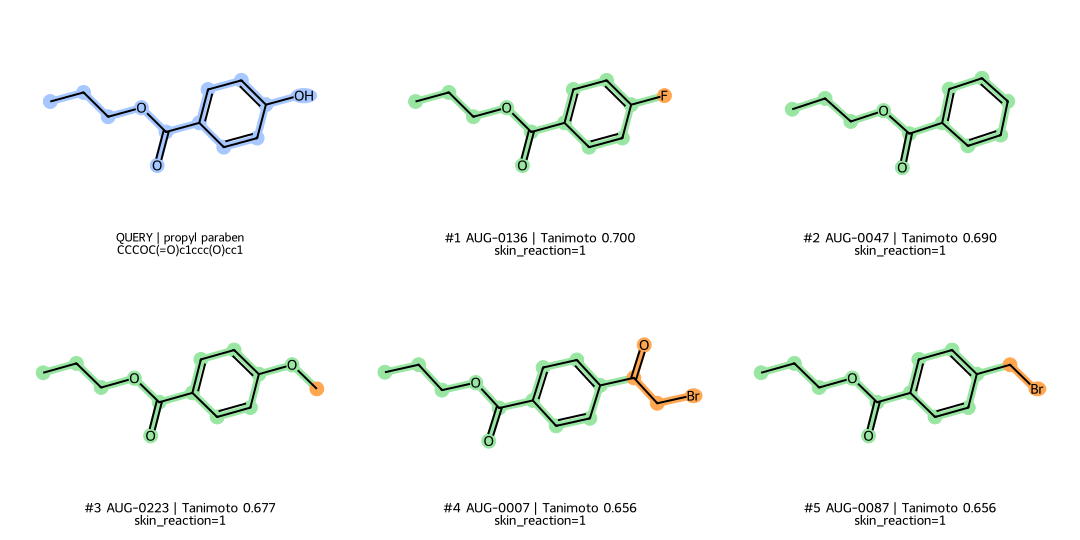

In [16]:
draw_top5(morgan_top5, "morgan_similarity", "Morgan / ECFP4 Top 5")

## 5. MACCS keys Top 5

Morgan과 같은 순서로 진행합니다. 먼저 Query와 Ref_list의 MACCS fingerprint를 각각 만듭니다.

In [17]:
# Query 분자를 167-bit MACCS fingerprint로 변환
query_maccs_fp = MACCSkeys.GenMACCSKeys(query_mol)

# Ref_list의 모든 분자도 같은 방법으로 변환
ref_maccs_fps = [MACCSkeys.GenMACCSKeys(i) for i in Ref_list["mol"]]

In [18]:
for i in range(len(ref_maccs_fps)):
    similarity = DataStructs.TanimotoSimilarity(query_maccs_fp, ref_maccs_fps[i])
    Ref_list.at[i, "maccs_similarity"] = similarity

maccs_top5 = Ref_list.sort_values(["maccs_similarity", "reference_id"], ascending=[False, True]).head(5)
maccs_top5

,reference_id,SMILES,skin_reaction,mol,morgan_similarity,maccs_similarity
297,AUG-0298,CCCOc1cccc(C(=O)O)c1,0,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.350000,1.000000
222,AUG-0223,CCCOC(=O)c1ccc(OC)cc1,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.677419,0.884615
53,AUG-0054,CCCOC(=O)c1ccc(O)c(Cl)c1,0,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.600000,0.800000
60,AUG-0061,CCCOC(=O)c1ccc(O)c(OC)c1,0,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.583333,0.800000
113,AUG-0114,CCC(C)OC(=O)c1ccc(O)cc1,0,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.529412,0.800000


MACCS keys Top 5


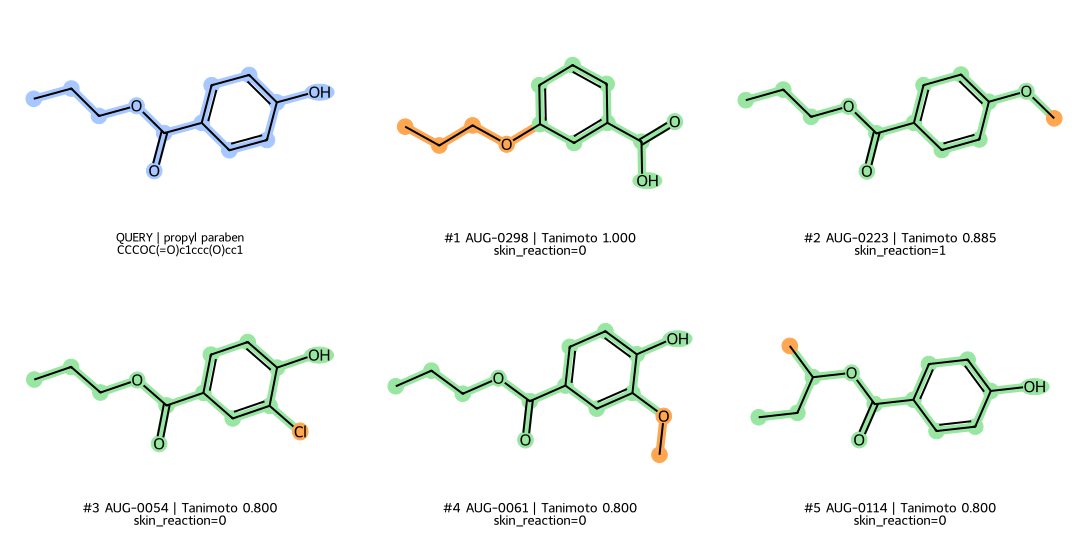

In [19]:
draw_top5(maccs_top5, "maccs_similarity", "MACCS keys Top 5")

## 6. Atom Pair Top 5

Atom Pair는 어떤 원자 쌍이 몇 개의 bond만큼 떨어져 있는지를 기록합니다. Morgan 때처럼 generator를 먼저 만듭니다.

In [20]:
# 2048-bit Atom Pair fingerprint를 만드는 generator
atom_pair_generator = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=2048)

query_atom_pair_fp = atom_pair_generator.GetFingerprint(query_mol)
ref_atom_pair_fps = [atom_pair_generator.GetFingerprint(i) for i in Ref_list["mol"]]

In [21]:
for i in range(len(ref_atom_pair_fps)):
    similarity = DataStructs.TanimotoSimilarity(query_atom_pair_fp, ref_atom_pair_fps[i])
    Ref_list.at[i, "atom_pair_similarity"] = similarity

atom_pair_top5 = Ref_list.sort_values(["atom_pair_similarity", "reference_id"], ascending=[False, True]).head(5)
atom_pair_top5

,reference_id,SMILES,skin_reaction,mol,morgan_similarity,maccs_similarity,atom_pair_similarity
135,AUG-0136,CCCOC(=O)c1ccc(F)cc1,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.700000,0.642857,0.719512
53,AUG-0054,CCCOC(=O)c1ccc(O)c(Cl)c1,0,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.600000,0.800000,0.673913
46,AUG-0047,CCCOC(=O)c1ccccc1,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.689655,0.750000,0.671053
86,AUG-0087,CCCOC(=O)c1ccc(CBr)cc1,1,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.656250,0.666667,0.670330
103,AUG-0104,CC(C)COC(=O)c1ccc(O)cc1,0,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.593750,0.769231,0.670330


Atom Pair Top 5


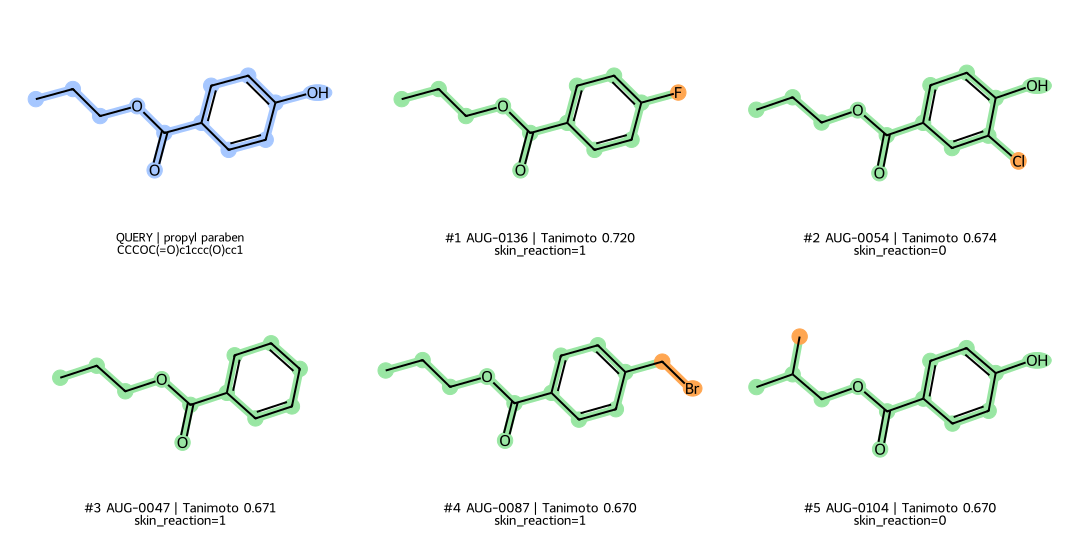

In [22]:
draw_top5(atom_pair_top5, "atom_pair_similarity", "Atom Pair Top 5")

## 7. PubChem-compatible 881-bit Top 5

PubChem fingerprint는 설치 과정이 복잡하므로 미리 계산한 881-bit 문자열을 CSV에서 불러옵니다. 문자열을 RDKit bit vector로 바꾼 뒤 같은 방식으로 비교합니다.

In [23]:
PubChem_FP = pd.read_csv(DATA_DIR / "pubchem_fp_881.csv")
PubChem_FP.head()

,record_type,compound_id,SMILES,pubchem_fp_881,on_bit_count
0,query,Q-01,CCCOC(=O)c1ccc(O)cc1,1100000001110000001100000000000000000000000000...,110
1,reference,AUG-0001,CCCCCCCCCCCCCBr,1110000001110000000000000000000000000000000100...,20
2,reference,AUG-0002,CN(C)CCCN,1100000001100011000000000000000000000000000000...,24
3,reference,AUG-0003,O=C1C=CC(=O)O1,0000000001100000001100000000000000000000000000...,32
4,reference,AUG-0004,NCCNCCO,1100000001100011001000000000000000000000000000...,33


In [24]:
query_pubchem_bits = PubChem_FP.loc[
    PubChem_FP["record_type"] == "query", "pubchem_fp_881"
].iloc[0]

# 문자열을 RDKit이 비교할 수 있는 bit vector로 변환
query_pubchem_fp = DataStructs.CreateFromBitString(query_pubchem_bits)

# reference 행만 따로 모은 뒤 하나씩 bit vector로 변환
pubchem_refs = PubChem_FP[PubChem_FP["record_type"] == "reference"].copy()
ref_pubchem_fps = []

for bit_string in pubchem_refs["pubchem_fp_881"]:
    fingerprint = DataStructs.CreateFromBitString(bit_string)
    ref_pubchem_fps.append(fingerprint)

In [25]:
# PubChem CSV의 reference_id와 fingerprint를 연결
pubchem_fp_by_id = dict(zip(pubchem_refs["compound_id"], ref_pubchem_fps))

# Ref_list의 순서에 맞게 fingerprint 목록을 다시 정렬
ref_pubchem_fps_ordered = [
    pubchem_fp_by_id[reference_id]
    for reference_id in Ref_list["reference_id"]
]

for i in range(len(ref_pubchem_fps_ordered)):
    similarity = DataStructs.TanimotoSimilarity(query_pubchem_fp, ref_pubchem_fps_ordered[i])
    Ref_list.at[i, "pubchem_similarity"] = similarity

pubchem_top5 = Ref_list.sort_values(["pubchem_similarity", "reference_id"], ascending=[False, True]).head(5)
pubchem_top5

,reference_id,SMILES,skin_reaction,mol,morgan_similarity,maccs_similarity,atom_pair_similarity,pubchem_similarity
103,AUG-0104,CC(C)COC(=O)c1ccc(O)cc1,0,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.593750,0.769231,0.670330,0.990991
113,AUG-0114,CCC(C)OC(=O)c1ccc(O)cc1,0,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.529412,0.800000,0.666667,0.990991
201,AUG-0202,CC(C)OC(=O)c1ccc(O)cc1,0,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.500000,0.615385,0.438776,0.990991
317,AUG-0318,C=CCOC(=O)c1ccc(O)cc1,0,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.545455,0.692308,0.566667,0.990909
296,AUG-0297,CC(C)(C)COC(=O)c1ccc(O)cc1,0,<rdkit.Chem.rdchem.Mol object at 0x00000266D37...,0.593750,0.689655,0.648936,0.982143


PubChem-compatible Top 5


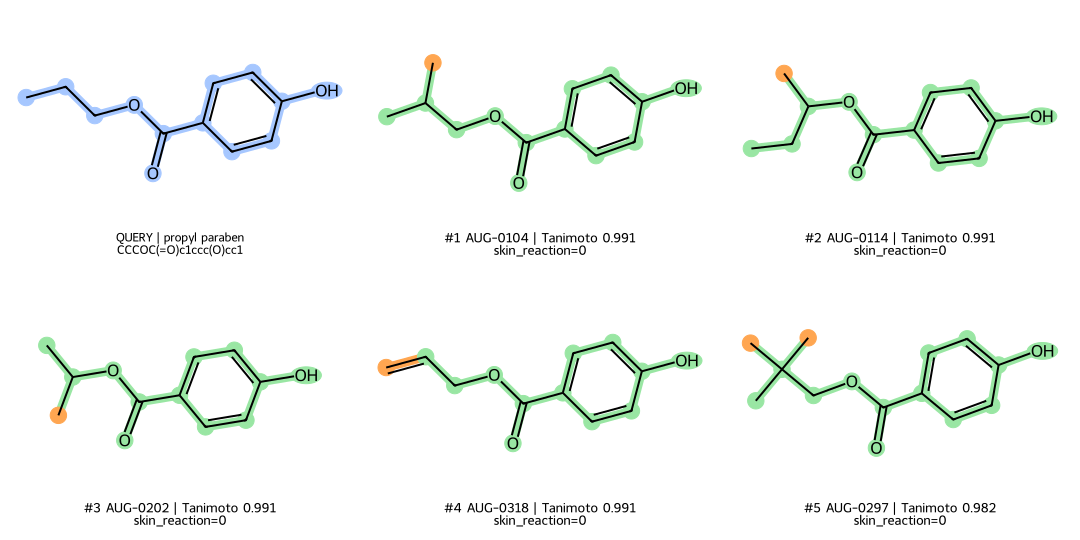

In [26]:
draw_top5(pubchem_top5, "pubchem_similarity", "PubChem-compatible Top 5")

## 8. PubChem fingerprint는 어느 bit에서 달랐을까?

차이가 나는 bit의 **수**가 같아도, 차이가 난 bit의 **위치(locus)** 까지 같다는 뜻은 아니다. PubChem Top 5에서 Query에만 켜진 bit와 reference에만 켜진 bit 번호를 직접 확인해보자!

In [27]:
query_on_bits = set(query_pubchem_fp.GetOnBits())
pubchem_bit_differences = []

for rank, (index, row) in enumerate(pubchem_top5.iterrows(), start=1):
    reference_fp = ref_pubchem_fps_ordered[index]
    reference_on_bits = set(reference_fp.GetOnBits())

    query_only = sorted(query_on_bits - reference_on_bits)
    reference_only = sorted(reference_on_bits - query_on_bits)

    pubchem_bit_differences.append({
        "순위": rank,
        "reference_id": row["reference_id"],
        "유사도": round(row["pubchem_similarity"], 3),
        "Query만 ON": query_only,
        "Reference만 ON": reference_only,
        "차이 개수": len(query_only) + len(reference_only),
    })

In [28]:
pubchem_difference_table = pd.DataFrame(pubchem_bit_differences)
pubchem_difference_table

,순위,reference_id,유사도,Query만 ON,Reference만 ON,차이 개수
0,1,AUG-0104,0.991,[],[335],1
1,2,AUG-0114,0.991,[],[339],1
2,3,AUG-0202,0.991,[],[339],1
3,4,AUG-0318,0.991,[374],[],1
4,5,AUG-0297,0.982,[],"[2, 334]",2


### 차이가 난 PubChem bit를 구조에서 찾아보기

PubChem 명세에 공개된 atom environment를 SMARTS로 표현하고, 해당 조건을 만족하는 **중심 탄소**를 빨간색으로 표시했다.

In [29]:
# PubChem 명세에 공개된 bit별 atom environment
pubchem_bit_smarts = {
    335: "[#6;H1]([#6])([#6])([#6])",  # 탄소 3개 + 수소 1개
    339: "[#6;H1]([#6])([#6])([#8])",  # 탄소 2개 + 산소 1개 + 수소 1개
    374: "[#6;H3]",                    # 수소 3개를 가진 탄소
}

def find_bit_centers(mol, bit):
    pattern = Chem.MolFromSmarts(pubchem_bit_smarts[bit])
    matches = mol.GetSubstructMatches(pattern)
    return [match[0] for match in matches]

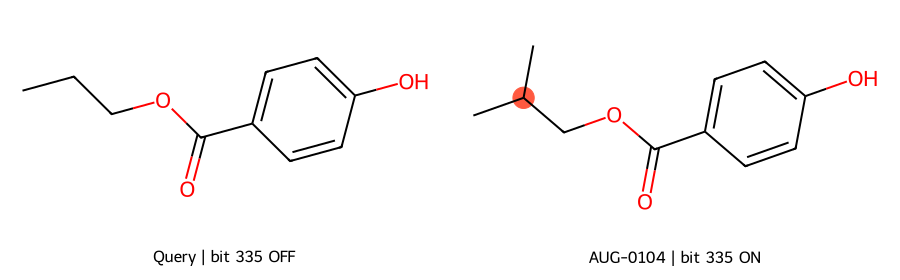

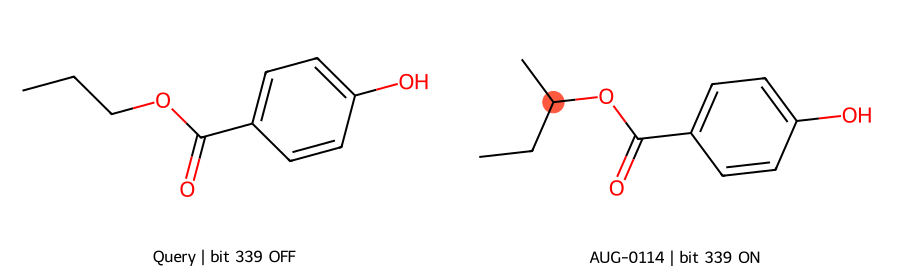

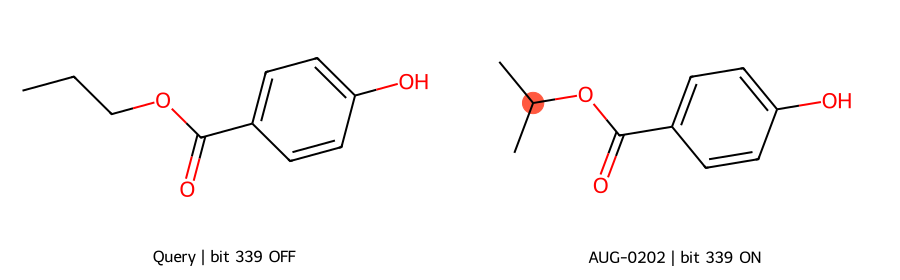

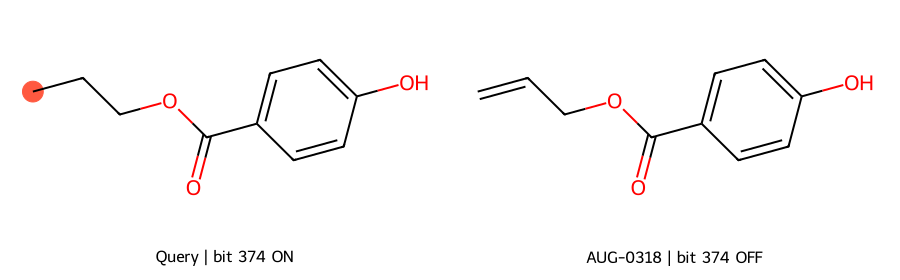

In [30]:
# PubChem fingerprint가 정확히 한 bit만 다른 네 pair
one_bit_pairs = [
    ("AUG-0104", 335),
    ("AUG-0114", 339),
    ("AUG-0202", 339),
    ("AUG-0318", 374),
]

for reference_id, bit in one_bit_pairs:
    row = Ref_list[Ref_list["reference_id"] == reference_id].iloc[0]
    reference_mol = row["mol"]

    query_centers = find_bit_centers(query_mol, bit)
    reference_centers = find_bit_centers(reference_mol, bit)

    image = Draw.MolsToGridImage(
        [query_mol, reference_mol],
        molsPerRow=2,
        subImgSize=(450, 280),
        legends=[
            f"Query | bit {bit} {'ON' if query_centers else 'OFF'}",
            f"{reference_id} | bit {bit} {'ON' if reference_centers else 'OFF'}",
        ],
        highlightAtomLists=[query_centers, reference_centers],
        highlightAtomColors=[
            {i: (1.0, 0.35, 0.25) for i in query_centers},
            {i: (1.0, 0.35, 0.25) for i in reference_centers},
        ],
    )
    display(image)

## 9. Fingerprint별 Top 5 구조를 다시 비교하기

Morgan / ECFP4 Top 5


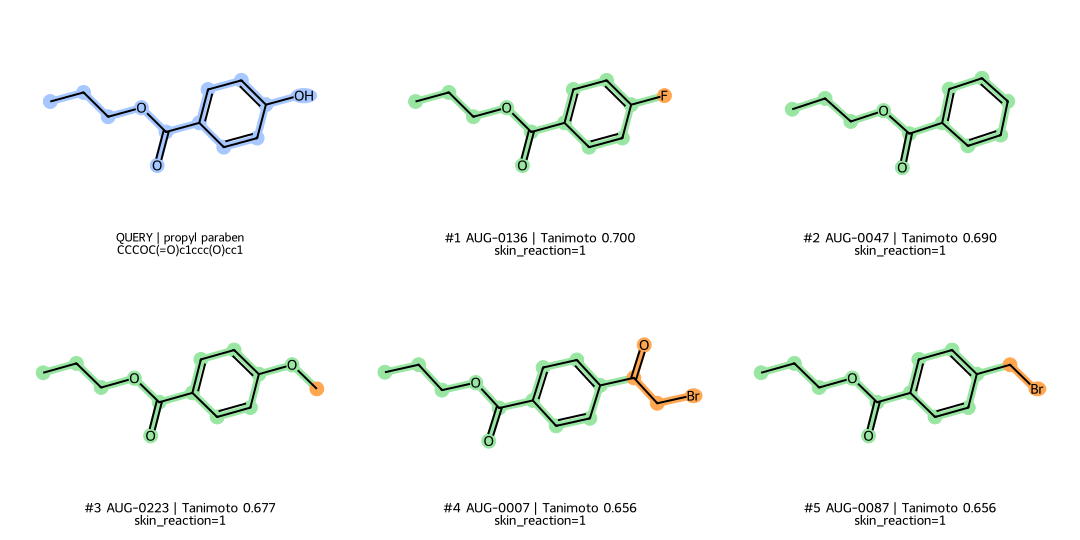

MACCS keys Top 5


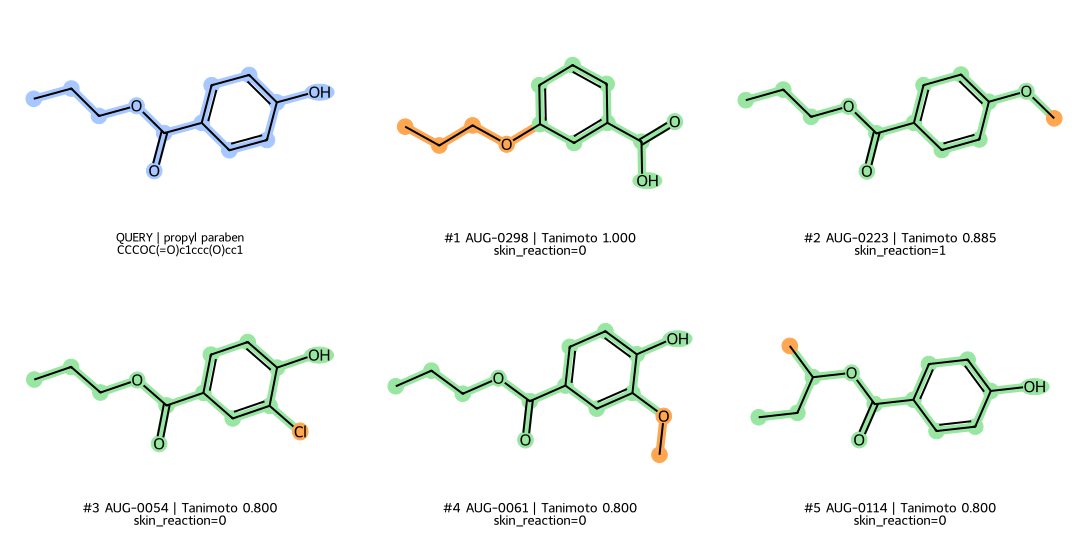

Atom Pair Top 5


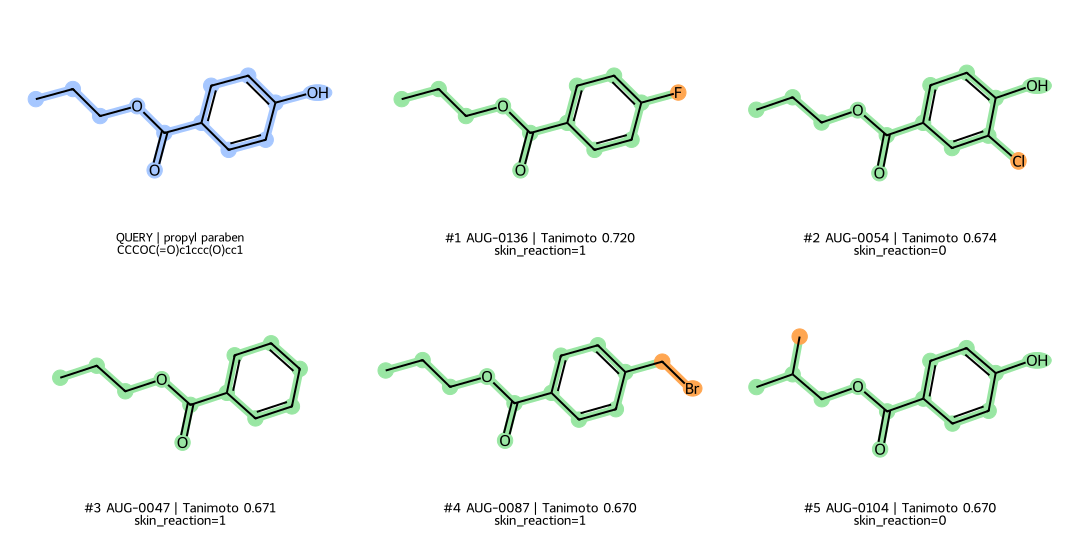

PubChem-compatible Top 5


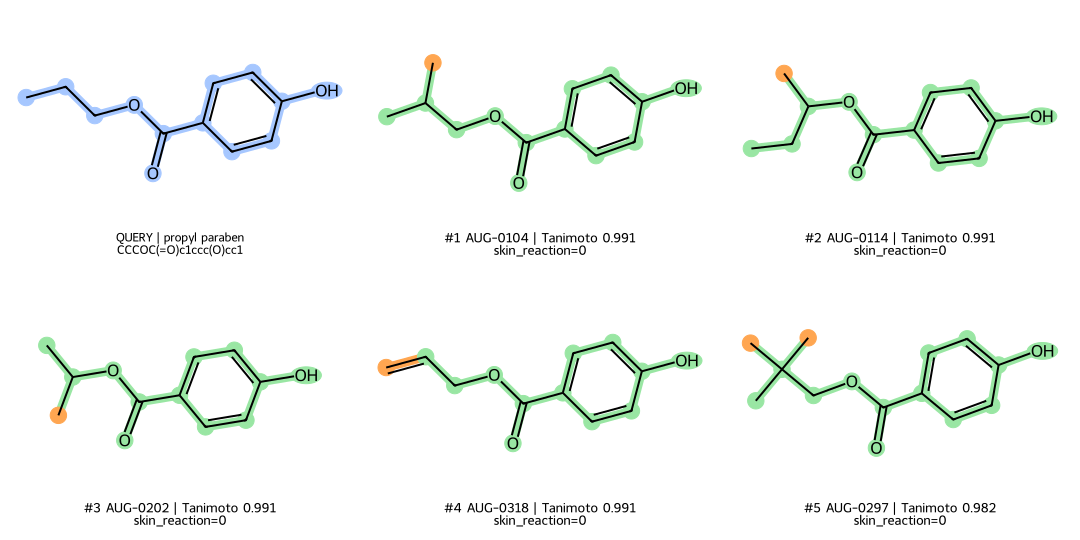

In [31]:
display(draw_top5(morgan_top5, "morgan_similarity", "Morgan / ECFP4 Top 5"))
display(draw_top5(maccs_top5, "maccs_similarity", "MACCS keys Top 5"))
display(draw_top5(atom_pair_top5, "atom_pair_similarity", "Atom Pair Top 5"))
display(draw_top5(pubchem_top5, "pubchem_similarity", "PubChem-compatible Top 5"))

## 10. Morgan / ECFP4가 긴 사슬을 구분하지 못하는 경우

> ECFP4 의 한계와 해결방법?

In [32]:
# 같은 벤젠 고리에 길이가 다른 alkyl chain을 연결
benzene = "c1ccccc1"

# Query: 벤젠 고리 + 탄소 20개의 직선형 사슬
long_chain_query = Chem.MolFromSmiles(benzene + "C" * 20)
long_chain_query_fp = morgan_generator.GetFingerprint(long_chain_query)

# Reference: 길이가 서로 다른 직선형 사슬 5개
chain_lengths = [6, 9, 14, 25, 30]
long_chain_refs = []
long_chain_similarities = []

for chain_length in chain_lengths:
    reference_mol = Chem.MolFromSmiles(benzene + "C" * chain_length)
    reference_fp = morgan_generator.GetFingerprint(reference_mol)
    similarity = DataStructs.TanimotoSimilarity(long_chain_query_fp, reference_fp)

    long_chain_refs.append(reference_mol)
    long_chain_similarities.append(similarity)

In [33]:
long_chain_result = pd.DataFrame({
    "구분": ["Query"] + [f"Ref {i}" for i in range(1, 6)],
    "alkyl chain 탄소 수": [20] + chain_lengths,
    "ECFP4 ON bit 수": [long_chain_query_fp.GetNumOnBits()]
        + [morgan_generator.GetFingerprint(mol).GetNumOnBits() for mol in long_chain_refs],
    "Query와 Tanimoto": [1.0] + long_chain_similarities,
})
long_chain_result

,구분,alkyl chain 탄소 수,ECFP4 ON bit 수,Query와 Tanimoto
0,Query,20,20,1.0
1,Ref 1,6,20,1.0
2,Ref 2,9,20,1.0
3,Ref 3,14,20,1.0
4,Ref 4,25,20,1.0
5,Ref 5,30,20,1.0


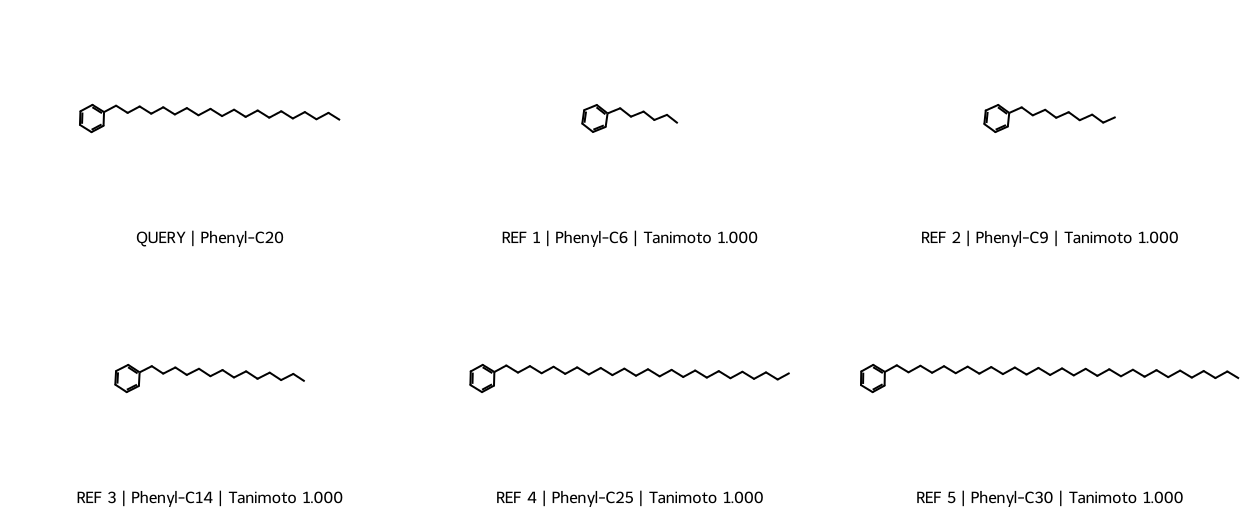

In [34]:
long_chain_mols = [long_chain_query] + long_chain_refs
long_chain_legends = ["QUERY | Phenyl-C20"]

for i in range(5):
    legend = f"REF {i + 1} | Phenyl-C{chain_lengths[i]} | Tanimoto {long_chain_similarities[i]:.3f}"
    long_chain_legends.append(legend)

Draw.MolsToGridImage(
    long_chain_mols,
    molsPerRow=3,
    subImgSize=(420, 260),
    legends=long_chain_legends,
)

### Chatbot 한테 "해줘" 하면 나오는 해결 방법은 bit 수를 늘리라는 답변이다. 과연 진짜 그게 도움이 될까?

두 가지 설정을 차례로 비교해보자

1. radius는 2로 유지하고 fingerprint 크기만 4096 bit로 확대
2. fingerprint 크기는 2048 bit로 유지하고 radius를 4로 확대

In [35]:
# 조건 1: radius 2, 4096 bit
morgan_4096_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=4096)
query_fp_4096 = morgan_4096_generator.GetFingerprint(long_chain_query)
ref_fps_4096 = [morgan_4096_generator.GetFingerprint(mol) for mol in long_chain_refs]

similarities_4096 = []
for reference_fp in ref_fps_4096:
    similarity = DataStructs.TanimotoSimilarity(query_fp_4096, reference_fp)
    similarities_4096.append(similarity)

# 조건 2: radius 4, 2048 bit
morgan_radius4_generator = rdFingerprintGenerator.GetMorganGenerator(radius=4, fpSize=2048)
query_fp_radius4 = morgan_radius4_generator.GetFingerprint(long_chain_query)
ref_fps_radius4 = [morgan_radius4_generator.GetFingerprint(mol) for mol in long_chain_refs]

similarities_radius4 = []
for reference_fp in ref_fps_radius4:
    similarity = DataStructs.TanimotoSimilarity(query_fp_radius4, reference_fp)
    similarities_radius4.append(similarity)

In [36]:
setting_comparison = pd.DataFrame({
    "reference": [f"Phenyl-C{length}" for length in chain_lengths],
    "radius 2 · 2048 bit": long_chain_similarities,
    "radius 2 · 4096 bit": similarities_4096,
    "radius 4 · 2048 bit": similarities_radius4,
})
setting_comparison.round(3)

,reference,radius 2 · 2048 bit,radius 2 · 4096 bit,radius 4 · 2048 bit
0,Phenyl-C6,1.0,1.0,0.707
1,Phenyl-C9,1.0,1.0,0.974
2,Phenyl-C14,1.0,1.0,1.000
3,Phenyl-C25,1.0,1.0,1.000
4,Phenyl-C30,1.0,1.0,1.000


대체 왜 이런 현상이 발생할까? 왜 Chatbot은 적절한 도움을 주지 못 했을까?

이것이 바로 우리가 **원리**를 이해해야하는 이유이다!